# HarnessChandelier

*Harness the Chandelier — connect to the center of your conversation.*  

**Topic Drift Tracking for Long-Running Agent Conversations**

In real-world AI agent interactions, users naturally drift across multiple topics —
then return to what they originally wanted.

HarnessChandelier doesn't try to prevent drift.
It **tracks it** — and finds the topic the user kept coming back to.

Like a chandelier at the center of a hall, the dominant topic stays fixed
no matter how much the conversation moves around it.

Built on:
- **BERTopic** + cuML UMAP/HDBSCAN — GPU-accelerated topic extraction
- **cuGraph PageRank** — topic importance ranking
- **Temporal edge weighting** — time-aware topic transition graph

Built for **Harness Engineering** workflows where conversations drift across topics.

This example demonstrates real-time dominant topic tracking 
in a live conversation stream.

As each new message arrives, HarnessChandelier continuously 
updates its understanding of the user's true intent — 
even as the user drifts across errors, color complaints, 
and layout issues.

The dominant topic emerges and stabilizes over time, 
without waiting for the conversation to end.

In [1]:
from harness_chandelier import HarnessChandelier
import time

live_messages = [
    # A - trip planning
    "I want to plan a trip to Japan next spring. Where should I start?",
    "Should I visit Tokyo first or Kyoto? I have 10 days total.",
    "What's the best way to get a JR Pass? Is it worth it?",
    
    # B - coding ..all of a sudden
    "Hey, totally different topic. I'm getting a TypeError in my Python code. Can you help?",
    "The error says 'NoneType object is not subscriptable'. What does that mean?",
    "Okay I fixed it. Thanks. It was a simple null check issue.",
    
    # C - life advice ..again, out of nowhere
    "Can I ask you something personal? I'm thinking about quitting my job.",
    "I've been at this company for 7 years but I feel stuck. No growth.",
    "My salary is okay but I'm not happy. Is it worth leaving for uncertainty?",
    "I have a family to support. That makes it harder to just quit.",
    
    # A - back to trip
    "Sorry, back to Japan. How much money should I budget for 10 days?",
    "Is Osaka worth visiting or should I skip it for more time in Kyoto?",
    "What about the bullet train? Is it as fast as they say?",
    
    # B - coding again
    "New coding problem. I'm trying to scrape a website but getting blocked.",
    "Should I use Selenium or BeautifulSoup for this?",
    "The website has JavaScript rendering. Does that change things?",
    "Got it working with Selenium. But it's really slow. Any tips?",
    
    # C - life advice again
    "Back to the job thing. I got a recruiter message today on LinkedIn.",
    "The new role pays 30% more but it's a startup. Risk vs reward?",
    "My wife thinks I should take it. My parents think I should stay safe.",
    "What would you do in my situation?",
    
    # A - back to trip ..again
    "Japan again - I found cheap flights for April. Should I book now?",
    "Cherry blossom season is April right? Will it overlap with my trip?",
    "Hotels in Tokyo are expensive. Should I try Airbnb instead?",
    "What neighborhoods in Tokyo are best for first timers?",
    
    # C - life advice again..
    "I applied to the startup job. Just did the first interview.",
    "They asked me where I see myself in 5 years. I had no idea what to say.",
    "I think I bombed it. Feel really discouraged right now.",
    "Maybe I should just stay where I am. At least it's stable.",
    
    # B - coding..lol
    "Different coding question. I'm learning React. Where should I start?",
    "Is it better to learn class components or just go straight to hooks?",
    "I built my first component but props aren't passing correctly.",
    "Never mind I figured it out. Missing curly braces. Classic.",
    
    # A -  back to trip ..again 2
    "Booked the Japan flights! April 3rd to April 13th.",
    "Now I need to figure out accommodation. 10 nights budget options?",
    "Should I do a ryokan experience even if it's expensive?",
    "I want to see Mount Fuji. Day trip from Tokyo or stay nearby?",
    "What about food allergies? I'm vegetarian. Is Japan hard for that?",
    
    # C - life advice again..for the last time I promise
    "I got a second interview at the startup! Maybe I didn't bomb it.",
    "They want me to do a technical presentation. I'm nervous.",
    "If I get this job my whole life changes. Is that scary or exciting?",
    "I keep going back and forth. Some days I want it, some days I don't.",
    
    # B - coding
    "My React app is almost done but deployment is confusing me.",
    "Vercel vs Netlify for a beginner? Which is easier?",
    "Deployed! But the environment variables aren't working in production.",
    
    # A - back to trip !!!!!
    "One month until Japan! Still haven't planned the actual itinerary.",
    "Can you give me a day by day plan for 10 days in Japan?",
    "Day 1 Tokyo, Day 2 Tokyo, Day 3 Kyoto... is that realistic?",
    
    # C - life advice again..last few messages
    "I got the job offer. They want an answer by Friday.",
    "I'm terrified. This is the biggest decision of my life.",
    "I think I'm going to take it. Wish me luck.",
    
    # A -  yes. really back to trip
    "Two weeks until Japan! I'm so excited. Any last minute tips?",
    "Should I get travel insurance? Is it worth it for Japan?",
    "Packing list for Japan in April? What should I not forget?",
    "I leave tomorrow. Any final advice?",
]

print("=== Real-time Intent Tracking ===\n")

=== Real-time Intent Tracking ===



In [2]:
ranker = HarnessChandelier(
    weights={"delta_time": +0.2}
)

tracking = [] 
for i, message in enumerate(live_messages):
    result = ranker.add_message(message)
    
    if result:
        tracking.append({
            "msg_num": i + 1,
            "main_topic": result.main_topic,
            "pagerank": result.pagerank.iloc[0]['pagerank']
        })
    time.sleep(0.5)  

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


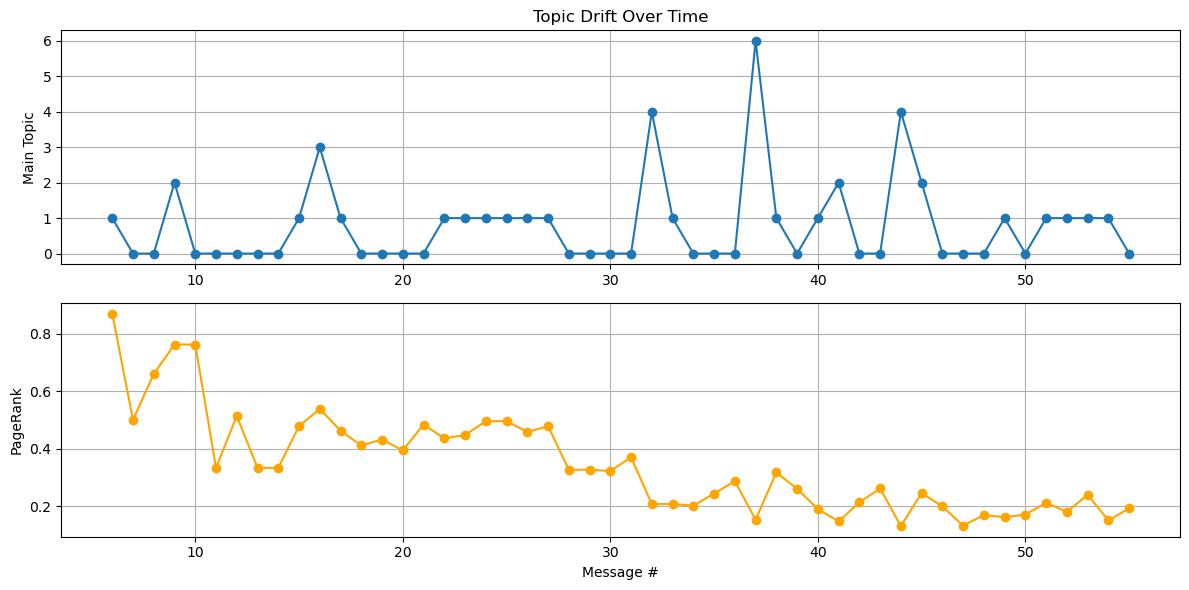

In [3]:
import matplotlib.pyplot as plt

msg_nums = [t["msg_num"] for t in tracking]
topics = [t["main_topic"] for t in tracking]
pageranks = [t["pagerank"] for t in tracking]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

ax1.plot(msg_nums, topics, marker='o')
ax1.set_ylabel("Main Topic")
ax1.set_title("Topic Drift Over Time")
ax1.grid(True)

ax2.plot(msg_nums, pageranks, marker='o', color='orange')
ax2.set_ylabel("PageRank")
ax2.set_xlabel("Message #")
ax2.grid(True)

plt.tight_layout()
plt.savefig("topic_drift.png")
plt.show()